# Model Evaluation and Comparison
This notebook compares multiple machine learning models (Logistic Regression, Linear SVM, KNN, and Naive Bayes) across different N-Gram ranges and TF-IDF feature sizes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# Set plot style
sns.set(style="whitegrid")

## 1. Load and Clean Data

In [2]:
df = pd.read_csv("course_recommendation_dataset.csv")

# Preprocessing
df['Course_Name'] = df['course_name'].fillna('').str.lower()
df['Description'] = df['course_description'].fillna('').str.lower()
df['Domain'] = df['course_domain'].fillna('').str.lower()
df['Description'] = df['Description'].str.replace('[^a-zA-Z ]', '', regex=True)
df['text'] = df['Course_Name'] + " " + df['Description']

# Remove empty rows
df = df[df['text'].str.strip() != '']
df = df[df['Domain'].str.strip() != '']

print(f"Dataset loaded with {len(df)} rows.")

Dataset loaded with 10000 rows.


## 2. Model Evaluation Grid Search
We will iterate through:
- **Models:** Logistic Regression, Linear SVM, KNN, Naive Bayes
- **N-Gram Ranges:** (1,1), (1,2), (1,3), (1,4)
- **Max Features:** 500, 1000, 1500

In [3]:
ngram_ranges = [(1,1), (1,2), (1,3), (1,4)]
max_features_list = [500, 1000, 1500]
all_results = []

for ngram in ngram_ranges:
    ngram_label = f"1-{ngram[1]} Gram"
    for max_feat in max_features_list:
        # Vectorization
        vectorizer = TfidfVectorizer(
            ngram_range=ngram,
            stop_words='english',
            max_features=max_feat
        )
        
        X = vectorizer.fit_transform(df['text'])
        y = df['Domain']

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        models = {
            "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
            "Linear SVM": LinearSVC(random_state=42),
            "KNN": KNeighborsClassifier(n_neighbors=5),
            "Naive Bayes (alpha=0.1)": MultinomialNB(alpha=0.1)
        }

        for name, model in models.items():
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            acc = accuracy_score(y_test, y_pred)
            
            all_results.append({
                "Model": name,
                "N-Gram": ngram_label,
                "Max Features": max_feat,
                "Accuracy": acc * 100
            })

res_df = pd.DataFrame(all_results)
print("Evaluation complete!")

Evaluation complete!


## 3. Results Visualization

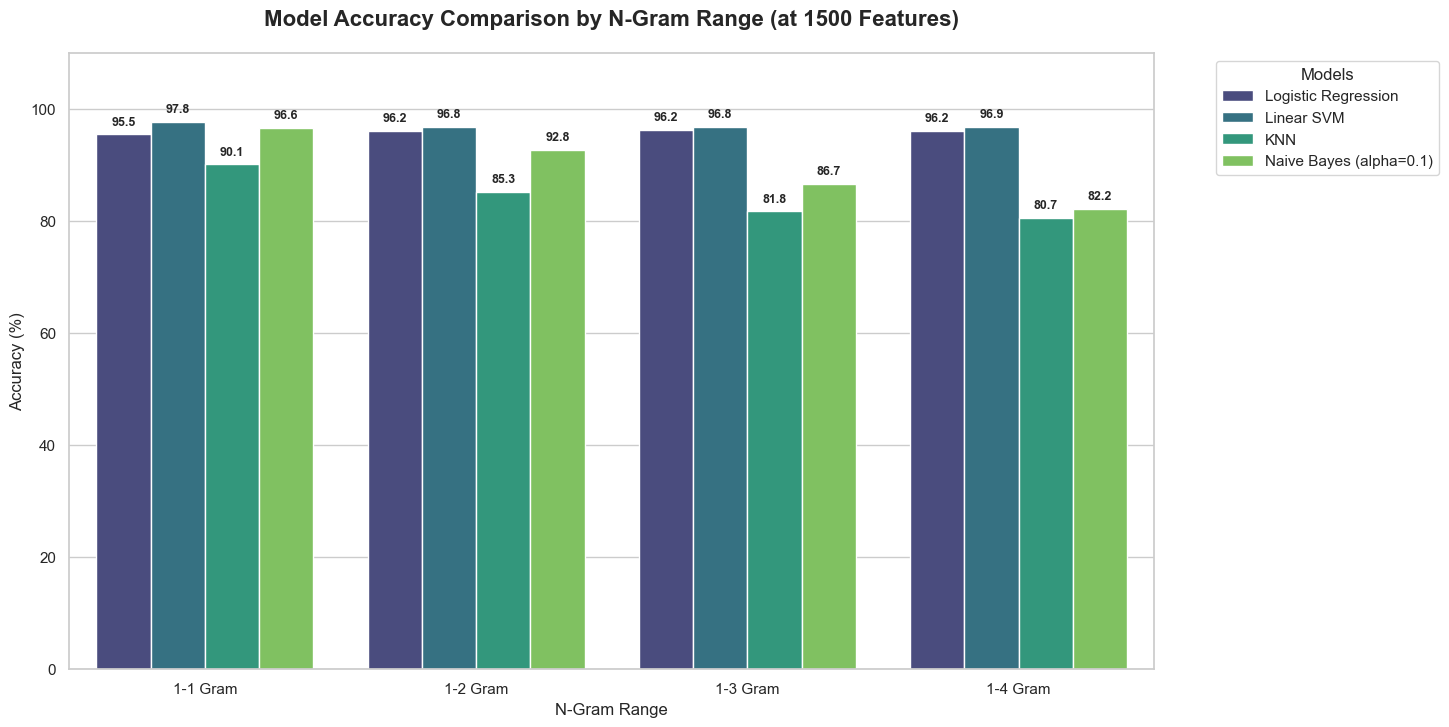

In [4]:
plt.figure(figsize=(14, 8))
best_feat_df = res_df[res_df['Max Features'] == 1500]
plot = sns.barplot(x='N-Gram', y='Accuracy', hue='Model', data=best_feat_df, palette='viridis')

plt.title('Model Accuracy Comparison by N-Gram Range (at 1500 Features)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Accuracy (%)')
plt.xlabel('N-Gram Range')
plt.ylim(0, 110)

for p in plot.patches:
    if p.get_height() > 0:
        plot.annotate(format(p.get_height(), '.1f'), 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha = 'center', va = 'center', 
                       xytext = (0, 9), 
                       textcoords = 'offset points',
                       fontsize=9, fontweight='bold')

plt.legend(title='Models', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## 4. Final Rankings
The table below shows the top 10 best-performing configurations.

In [5]:
res_df.sort_values(by='Accuracy', ascending=False).head(10)

,Model,N-Gram,Max Features,Accuracy
5,Linear SVM,1-1 Gram,1000,97.75
9,Linear SVM,1-1 Gram,1500,97.75
1,Linear SVM,1-1 Gram,500,96.95
45,Linear SVM,1-4 Gram,1500,96.90
21,Linear SVM,1-2 Gram,1500,96.80
33,Linear SVM,1-3 Gram,1500,96.80
17,Linear SVM,1-2 Gram,1000,96.75
29,Linear SVM,1-3 Gram,1000,96.65
13,Linear SVM,1-2 Gram,500,96.60
11,Naive Bayes (alpha=0.1),1-1 Gram,1500,96.60
